# Wizualizacja danych z Pandas, Matplotlib i Seaborn

## 1. Import bibliotek

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Ustawienia dla czytelności wykresów
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")  # Styl seaborn

## 2. Przygotowanie danych

In [ ]:
data = {
    "wojewodztwo": ["łódzkie", "łódzkie", "łódzkie", "łódzkie", "łódzkie",
                     "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie"],
    "rok": [2000, 2005, 2010, 2015, 2020,
            2000, 2005, 2010, 2015, 2020],
    "populacja_mln": [2.67, 2.59, 2.54, 2.49, 2.44,
                      5.07, 5.14, 5.24, 5.35, 5.42]
}
df_woj = pd.DataFrame(data)
df_woj.head(10)

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44
5,mazowieckie,2000,5.07
6,mazowieckie,2005,5.14
7,mazowieckie,2010,5.24
8,mazowieckie,2015,5.35
9,mazowieckie,2020,5.42


In [ ]:
df_woj.keys()

Index(['wojewodztwo', 'rok', 'populacja_mln'], dtype='object')

In [ ]:
# Filtracja danych dla każdego województwa
mazowieckie = df_woj[df_woj["wojewodztwo"] == "mazowieckie"]
lodzkie = df_woj[df_woj["wojewodztwo"] == "łódzkie"]

In [ ]:
lodzkie

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44


## 3. WYKRES LINIOWY (Line Plot)

**Zastosowanie:** Przedstawianie zmian w czasie, trendów

(1999.0, 2021.0)

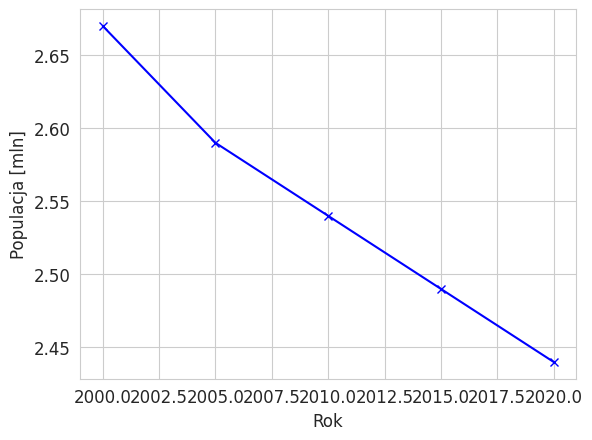

In [ ]:
plt.plot(lodzkie["rok"], lodzkie["populacja_mln"], "bx-")
plt.xlabel("Rok")
plt.ylabel("Populacja [mln]")
plt.xlim([1999, 2021])

Text(0, 0.5, 'pop [mln]')

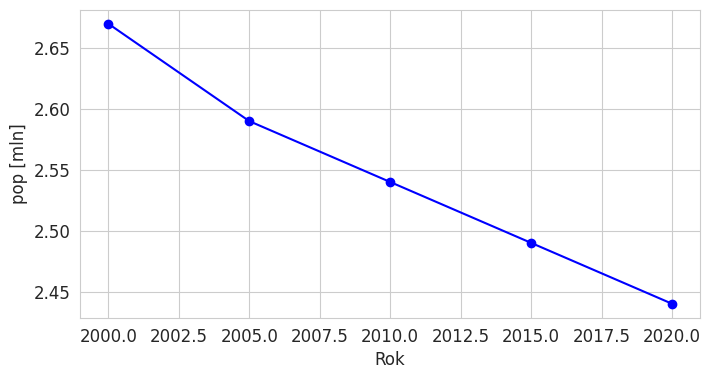

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax.set_xlabel("Rok")
ax.set_ylabel("pop [mln]")

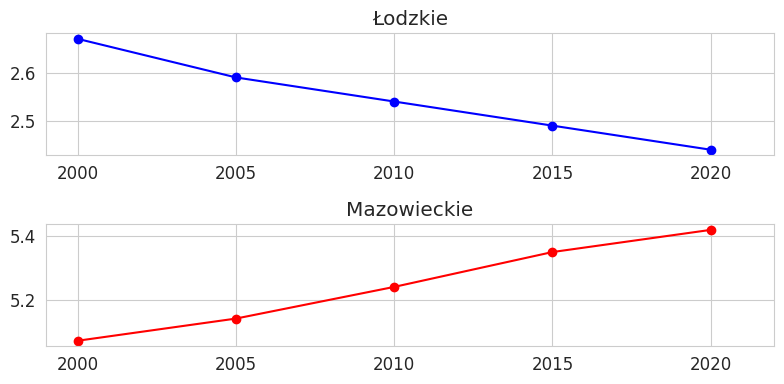

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4))
ax[0].plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax[0].set_title("Łodzkie")
ax[1].plot(mazowieckie["rok"], mazowieckie["populacja_mln"], 'ro-')
ax[0].set_xlim([1999, 2022])
ax[1].set_xlim([1999, 2022])
ax[1].set_title("Mazowieckie")
plt.tight_layout()

### Bezpośrednio `plot` na pandas DataFrame

<Axes: xlabel='rok'>

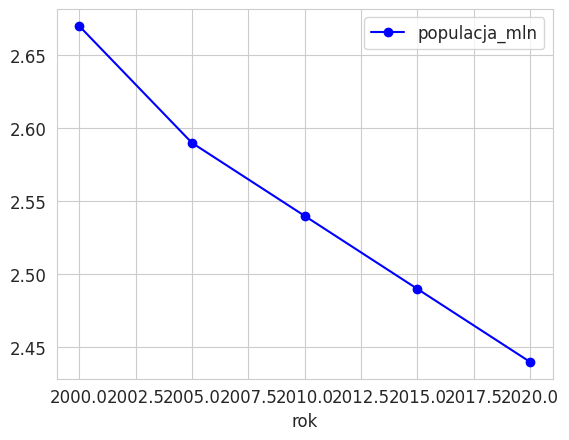

In [ ]:
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue")

<Axes: xlabel='rok'>

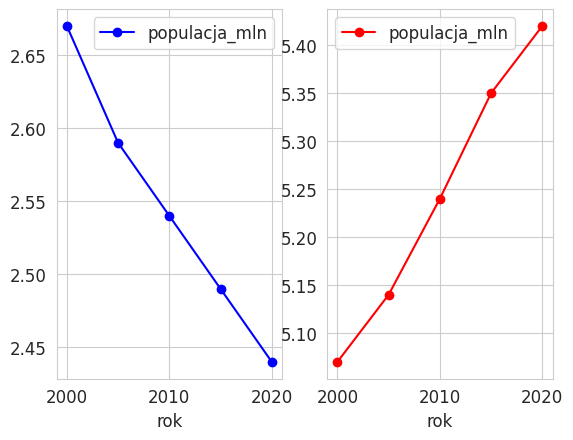

In [ ]:
fig, ax = plt.subplots(1, 2)
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue", ax=ax[0])
mazowieckie.plot(x="rok", y="populacja_mln", marker="o", color="red", ax=ax[1])

## 4. WYKRES PUNKTOWY (Scatter Plot)

 **Zastosowanie:** Pokazywanie relacji między dwiema zmiennymi

In [ ]:
# Generowanie dodatkowych danych dla scatter plot
np.random.seed(42)
scatter_data = pd.DataFrame({
    'temperatura': np.random.uniform(15, 35, 1500),
    'sprzedaz_lodow': np.random.uniform(50, 300, 1500)
})
# Dodajemy korelację
scatter_data['sprzedaz_lodow'] = scatter_data['sprzedaz_lodow'] + scatter_data['temperatura'] * 5

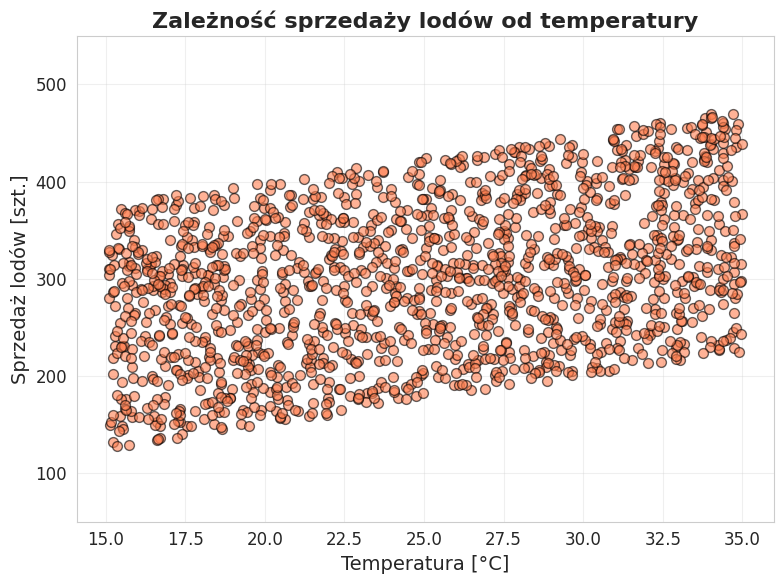

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(scatter_data['temperatura'], scatter_data['sprzedaz_lodow'],
            s=50, alpha=0.6, c='coral', edgecolors='black', linewidth=1)

plt.title('Zależność sprzedaży lodów od temperatury', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. WYKRES SŁUPKOWY (Bar Plot)

 **Zastosowanie:** Porównywanie wartości między kategoriami

In [ ]:
# Dane dla wykresu słupkowego - populacja miast w dwóch różnych latach
miasta_data = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Łódź', 'Wrocław', 'Poznań'],
    'populacja_2022': [1795, 800, 670, 672, 545],
    'populacja_2010': [1700, 757, 730, 632, 550]
})

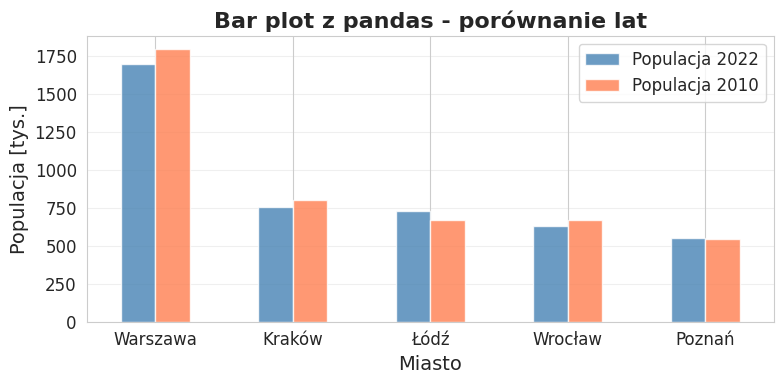

In [ ]:
# Bar plot - Pandas

miasta_data.plot.bar(x='miasto', y=['populacja_2010', 'populacja_2022'],
                     figsize=(8, 4), color=['steelblue', 'coral'], alpha=0.8)
plt.title('Bar plot z pandas - porównanie lat', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Populacja [tys.]', fontsize=14)
plt.legend(['Populacja 2022', 'Populacja 2010'], fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Jak to zrobić z Seaborn?

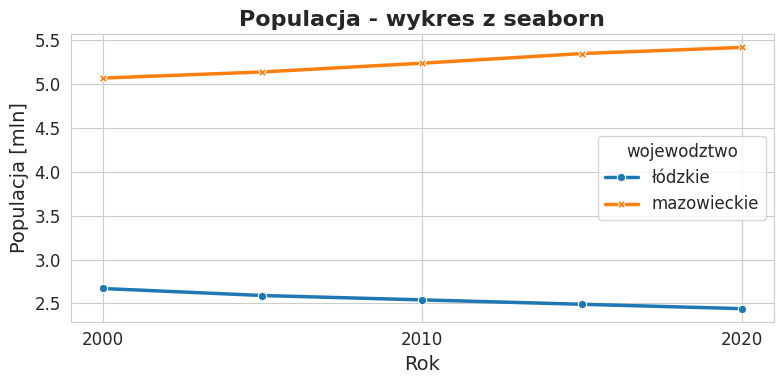

In [ ]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_woj, x='rok', y='populacja_mln', hue='wojewodztwo',
             style='wojewodztwo', markers=True, dashes=False, linewidth=2.5)

plt.title('Populacja - wykres z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Populacja [mln]', fontsize=14)
plt.xticks([2000, 2010, 2020])
plt.tight_layout()
plt.show()

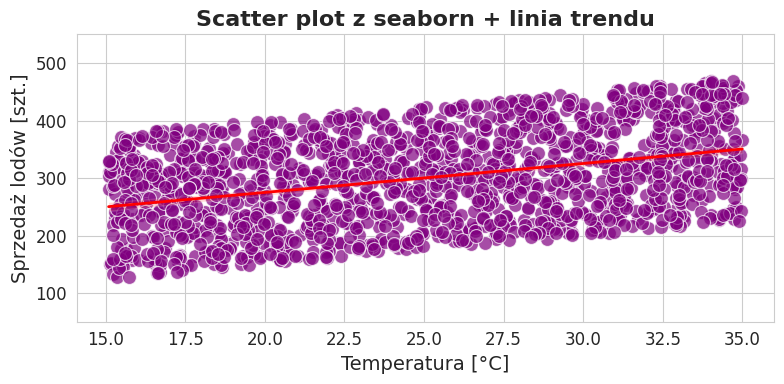

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
                s=100, alpha=0.7, color='purple')
sns.regplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Scatter plot z seaborn + linia trendu', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.tight_layout()
plt.show()

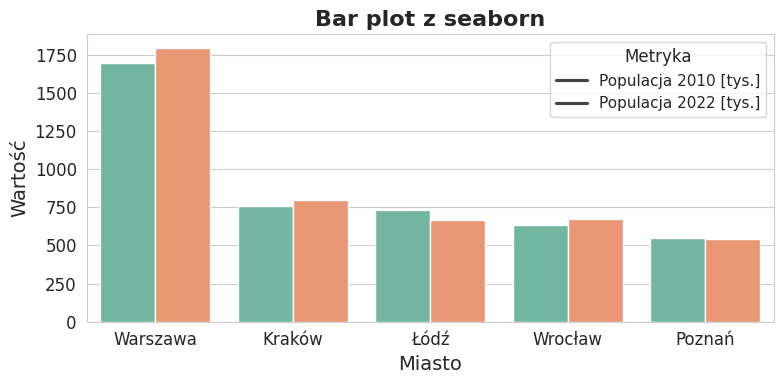

In [ ]:
# Bar plot - Seaborn

# Przekształcenie danych do formatu długiego (long format)
miasta_long = pd.melt(miasta_data, id_vars=['miasto'],
                      value_vars=['populacja_2010', 'populacja_2022'],
                      var_name='Typ', value_name='Wartość')

plt.figure(figsize=(8, 4))
sns.barplot(data=miasta_long, x='miasto', y='Wartość', hue='Typ', palette='Set2')
plt.title('Bar plot z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Wartość', fontsize=14)
plt.legend(title='Metryka', labels=['Populacja 2010 [tys.]', 'Populacja 2022 [tys.]'], fontsize=11)
plt.tight_layout()
plt.show()

# ZADANIA


## Zadanie 1: Podstawy DataFrame i wykres liniowy

**Dane:** Liczba mieszkańców Warszawy i Łodzi w wybranych latach:

| Rok  | Warszawa  | Łódź      |
|------|-----------|-----------|
| 2002 | 1672000   | 789318    |
| 2011 | 1707000   | 728892    |
| 2015 | 1740000   | 700982    |
| 2022 | 1795000   | 670642    |

**Polecenia:**
1. Utwórz słownik z powyższymi danymi
2. Stwórz DataFrame z tego słownika
5. **Stwórz wykres liniowy** pokazujący zmiany populacji obu miast w czasie
   - Użyj różnych kolorów i markerów dla każdego miasta
    - Dodaj tytuł, opisy osi i legendę
    - Wypróbuj wszystkie 3 metody (matplotlib, pandas, seaborn)

DataFrame z danymi miast:
    Rok  Warszawa    Łódź
0  2002   1672000  789318
1  2011   1707000  728892
2  2015   1740000  700982
3  2022   1795000  670642

 Polecenie 3


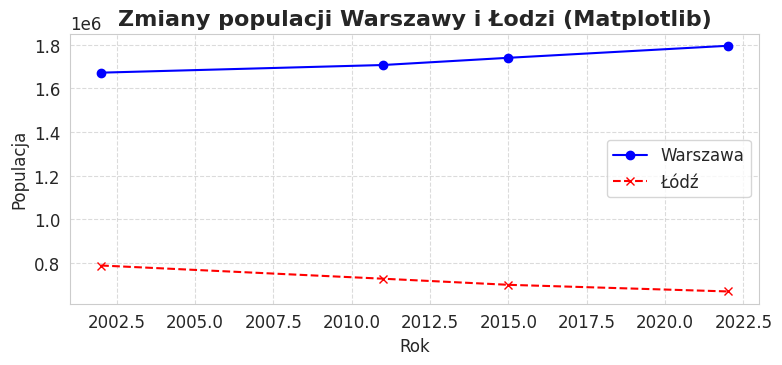

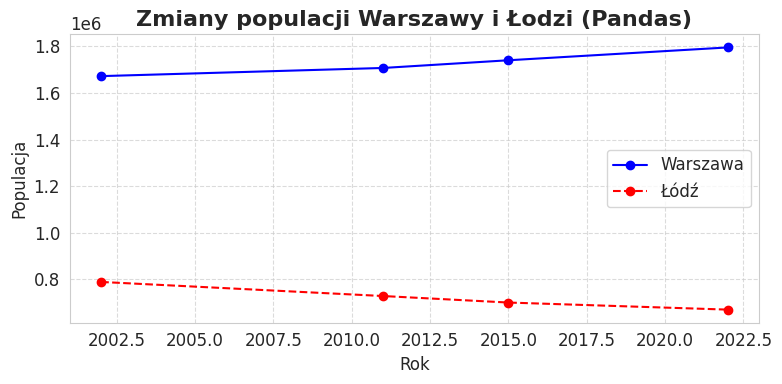

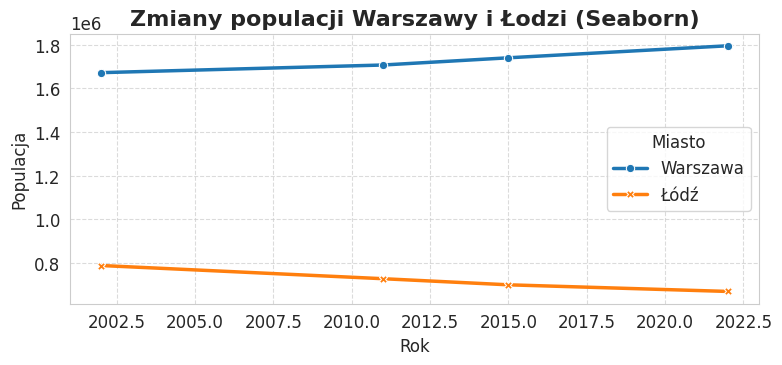

In [ ]:
dane_miasta = {
    'Rok': [2002, 2011, 2015, 2022],
    'Warszawa': [1672000, 1707000, 1740000, 1795000],
    'Łódź': [789318, 728892, 700982, 670642]
}

df_miasta = pd.DataFrame(dane_miasta)

print("DataFrame z danymi miast:")
print(df_miasta)


print("\n Polecenie 3")

df_miasta_plot = df_miasta.set_index('Rok')

plt.figure(figsize=(8, 4))
plt.plot(df_miasta['Rok'], df_miasta['Warszawa'], 'o-', color='blue', label='Warszawa')
plt.plot(df_miasta['Rok'], df_miasta['Łódź'], 'x--', color='red', label='Łódź')

plt.title('Zmiany populacji Warszawy i Łodzi (Matplotlib)', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Populacja', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df_miasta_plot = df_miasta.set_index('Rok')

plt.figure(figsize=(8, 4))
df_miasta_plot.plot(kind='line', marker='o', ax=plt.gca(), color=['blue', 'red'], style=['-', '--'])

plt.title('Zmiany populacji Warszawy i Łodzi (Pandas)', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Populacja', fontsize=12)
plt.legend(['Warszawa', 'Łódź'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df_miasta_long = df_miasta.melt(id_vars=['Rok'], var_name='Miasto', value_name='Populacja')

plt.figure(figsize=(8, 4))
sns.lineplot(data=df_miasta_long, x='Rok', y='Populacja', hue='Miasto', style='Miasto', markers=True, dashes=False, linewidth=2.5)

plt.title('Zmiany populacji Warszawy i Łodzi (Seaborn)', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Populacja', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## Zadanie 2: Analiza danych o pojazdach w Łodzi

Dane pochodzą z portalu otwartych danych miasta Łodzi: https://otwarte.miasto.lodz.pl/transport_komunikacja/

### Do zrobienia:

1. **Wczytaj plik** `Pojazdy-ogolem-w-Lodzi.csv`

2. **Utwórz wykres punktowy** pokazujący zmianę liczby:
   - samochody osobowe
   - autobusy ogółem
   
   na przestrzeni lat. Dla każdego typu zrób osobny wykres.

3. **Utwórz wykres słupkowy** dla roku 2020 przedstawiający liczbę:
   - autobusów
   - samochodów osobowych
   - samochodów ciężarowych
   - motocykli

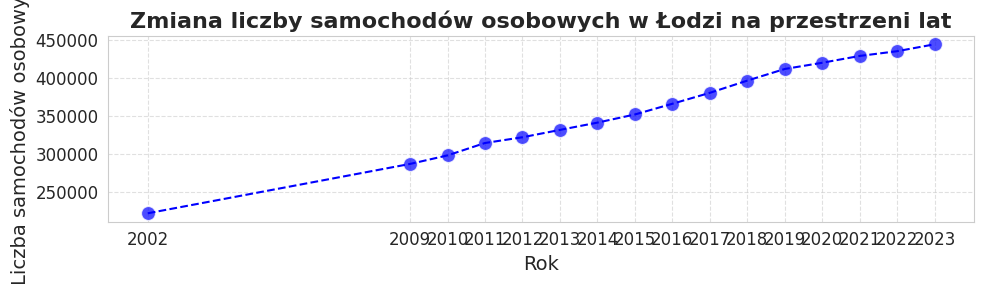

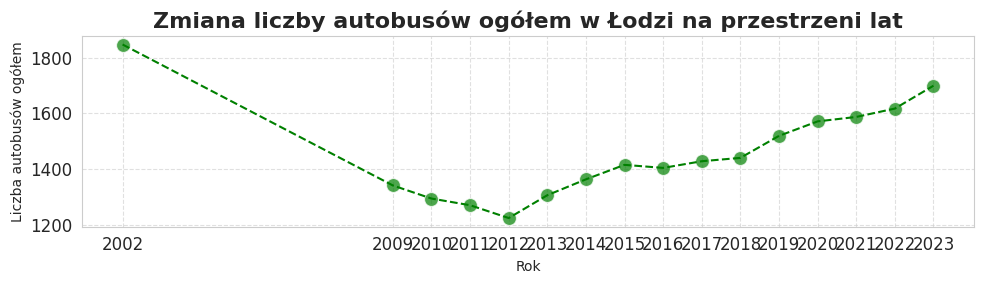

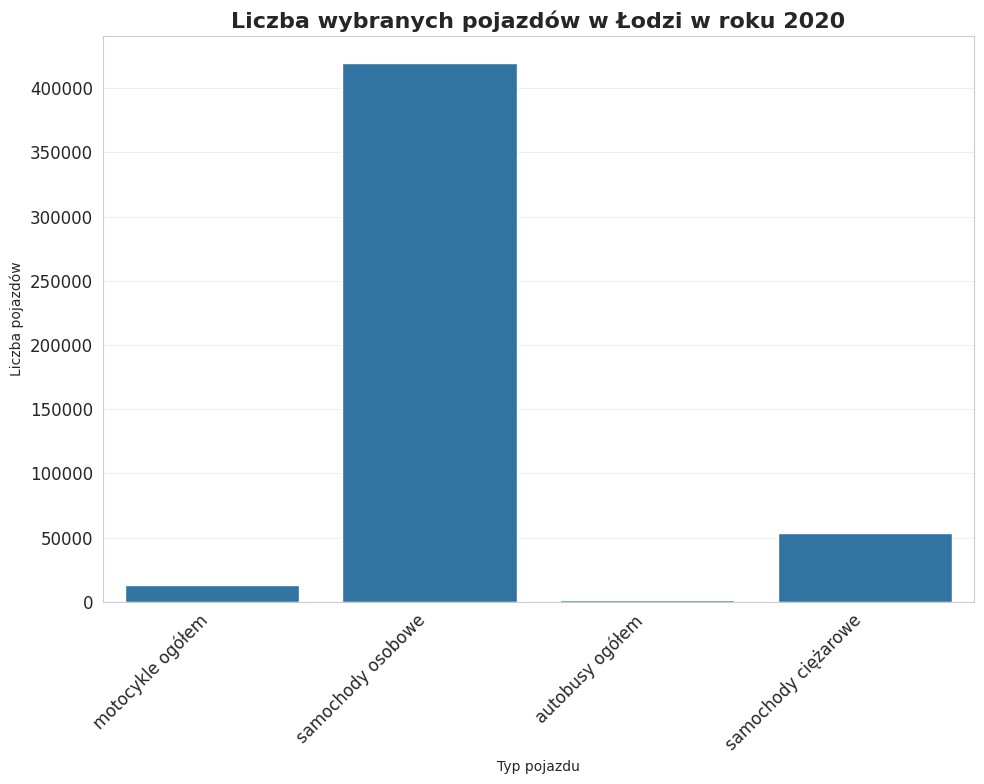

In [ ]:
df = pd.read_csv('pojazdy-ogoem-w-Lodzi.csv', sep=';')
df.columns = ['nazwa_zbioru', 'rok', 'wartosc', 'typ_pojazdu']

samochody_osobowe_df = df[df['typ_pojazdu'] == 'samochody osobowe']

plt.figure(figsize=(10, 3))
sns.scatterplot(data=samochody_osobowe_df, x='rok', y='wartosc', s=100, color='blue', alpha=0.7)
sns.lineplot(data=samochody_osobowe_df, x='rok', y='wartosc', color='blue', linestyle='--')
plt.title('Zmiana liczby samochodów osobowych w Łodzi na przestrzeni lat', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Liczba samochodów osobowych', fontsize=14)
plt.xticks(samochody_osobowe_df['rok'].unique().astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

autobusy_ogolem_df = df[df['typ_pojazdu'] == 'autobusy ogółem']

plt.figure(figsize=(10, 3))
sns.scatterplot(data=autobusy_ogolem_df, x='rok', y='wartosc', s=100, color='green', alpha=0.7)
sns.lineplot(data=autobusy_ogolem_df, x='rok', y='wartosc', color='green', linestyle='--')
plt.title('Zmiana liczby autobusów ogółem w Łodzi na przestrzeni lat', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=10)
plt.ylabel('Liczba autobusów ogółem', fontsize=10)
plt.xticks(autobusy_ogolem_df['rok'].unique().astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

df_2020 = df[df['rok'] == 2020]

typy_pojazdow = ['autobusy ogółem', 'samochody osobowe', 'samochody ciężarowe', 'motocykle ogółem']
df_2020_wybrane = df_2020[df_2020['typ_pojazdu'].isin(typy_pojazdow)]

plt.figure(figsize=(10, 8))
sns.barplot(x='typ_pojazdu', y='wartosc', data=df_2020_wybrane)

plt.title('Liczba wybranych pojazdów w Łodzi w roku 2020', fontsize=16, fontweight='bold')
plt.xlabel('Typ pojazdu', fontsize=10)
plt.ylabel('Liczba pojazdów', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()